# COVID-19 Data Analysis
**Name:** Tharun R
**Subject:** Data Analysis using Python
**Dataset:** https://raw.githubusercontent.com/SR1608/Datasets/main/covid-data.csv


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline


## 1. Import the Dataset


In [2]:
url = 'https://raw.githubusercontent.com/SR1608/Datasets/main/covid-data.csv'
df = pd.read_csv(url)
df.head()


,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
0,AFG,Asia,Afghanistan,31/12/19,NaN,0.0,NaN,NaN,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
1,AFG,Asia,Afghanistan,01/01/20,NaN,0.0,NaN,NaN,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
2,AFG,Asia,Afghanistan,02/01/20,NaN,0.0,NaN,NaN,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
3,AFG,Asia,Afghanistan,03/01/20,NaN,0.0,NaN,NaN,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
4,AFG,Asia,Afghanistan,04/01/20,NaN,0.0,NaN,NaN,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498


## 2. High Level Data Understanding


In [3]:
# a. number of rows and columns
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])


Rows: 57394
Columns: 49


In [4]:
# b. data types
print(df.dtypes)


iso_code                                  str
continent                                 str
location                                  str
date                                      str
total_cases                           float64
new_cases                             float64
new_cases_smoothed                    float64
total_deaths                          float64
new_deaths                            float64
new_deaths_smoothed                   float64
total_cases_per_million               float64
new_cases_per_million                 float64
new_cases_smoothed_per_million        float64
total_deaths_per_million              float64
new_deaths_per_million                float64
new_deaths_smoothed_per_million       float64
reproduction_rate                     float64
icu_patients                          float64
icu_patients_per_million              float64
hosp_patients                         float64
hosp_patients_per_million             float64
weekly_icu_admissions             

In [5]:
# c. info and describe
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 57394 entries, 0 to 57393
Data columns (total 49 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   iso_code                            57071 non-null  str    
 1   continent                           56748 non-null  str    
 2   location                            57394 non-null  str    
 3   date                                57394 non-null  str    
 4   total_cases                         53758 non-null  float64
 5   new_cases                           56465 non-null  float64
 6   new_cases_smoothed                  55652 non-null  float64
 7   total_deaths                        44368 non-null  float64
 8   new_deaths                          56465 non-null  float64
 9   new_deaths_smoothed                 55652 non-null  float64
 10  total_cases_per_million             53471 non-null  float64
 11  new_cases_per_million               56401 non-null  

In [6]:
df.describe()


,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths_per_million,...,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
count,5.375800e+04,56465.000000,55652.000000,4.436800e+04,56465.000000,55652.000000,53471.000000,56401.000000,55587.000000,44096.000000,...,50367.000000,33571.000000,51013.000000,52881.000000,39669.000000,39156.000000,24176.000000,45936.000000,56336.000000,49247.000000
mean,1.677974e+05,1953.576941,1920.431953,6.858639e+03,47.054317,46.835439,3139.099982,39.344804,38.403211,95.335293,...,20620.172071,12.435453,252.646642,8.070269,10.741569,32.642686,52.089636,3.089724,73.937780,0.722223
std,1.693038e+06,18269.650340,17777.391785,5.578081e+04,390.853776,378.272794,6183.455260,133.985155,101.649441,180.721699,...,20310.999832,19.427924,117.522344,4.189605,10.470743,13.453566,31.645306,2.513193,7.397016,0.153261
min,1.000000e+00,-8261.000000,-552.000000,1.000000e+00,-1918.000000,-232.143000,0.001000,-2212.545000,-269.978000,0.000000,...,661.240000,0.100000,79.370000,0.990000,0.100000,7.700000,1.188000,0.100000,53.280000,0.354000
25%,1.800000e+02,0.000000,0.857000,1.300000e+01,0.000000,0.000000,90.033000,0.000000,0.260000,3.977750,...,5321.444000,0.500000,156.139000,5.310000,1.900000,21.400000,21.222000,1.300000,69.870000,0.601000
50%,2.070000e+03,14.000000,19.429000,8.400000e+01,0.000000,0.286000,593.663000,2.194000,3.863000,20.383000,...,13913.839000,2.000000,238.339000,7.110000,6.400000,31.400000,52.232000,2.500000,75.345000,0.752000
75%,2.235675e+04,235.000000,245.286000,7.270000e+02,4.000000,4.000000,3487.050000,25.941000,29.678500,90.571250,...,31400.840000,18.100000,318.991000,10.390000,19.600000,40.900000,83.741000,4.200000,79.380000,0.847000
max,5.515465e+07,646281.000000,584981.857000,1.328537e+06,10600.000000,9027.714000,76541.772000,8652.658000,2472.188000,1248.014000,...,116935.600000,77.600000,724.417000,30.530000,44.000000,78.100000,98.999000,13.800000,86.750000,0.953000


## 3. Low Level Data Understanding


In [7]:
# a. count of unique values in location column
print(df['location'].nunique())


216


In [8]:
# b. continent with maximum frequency
print(df['continent'].value_counts())


continent
Europe           14828
Africa           13637
Asia             13528
North America     9116
South America     3404
Oceania           2235
Name: count, dtype: int64


In [9]:
# c. max and mean of total_cases
print('Max:', df['total_cases'].max())
print('Mean:', df['total_cases'].mean())


Max: 55154651.0
Mean: 167797.3688753302


In [10]:
# d. 25, 50, 75 quartile of total_deaths
print('25%:', df['total_deaths'].quantile(0.25))
print('50%:', df['total_deaths'].quantile(0.50))
print('75%:', df['total_deaths'].quantile(0.75))


25%: 13.0
50%: 84.0
75%: 727.0


In [11]:
# e. continent with max human_development_index
print(df.groupby('continent')['human_development_index'].max().idxmax())


Europe


In [12]:
# f. continent with minimum gdp_per_capita
print(df.groupby('continent')['gdp_per_capita'].min().idxmin())


Africa


## 4. Filter the Dataframe


In [13]:
cols = ['continent','location','date','total_cases','total_deaths','gdp_per_capita','human_development_index']
df = df[cols]
df.head()


,continent,location,date,total_cases,total_deaths,gdp_per_capita,human_development_index
0,Asia,Afghanistan,31/12/19,NaN,NaN,1803.987,0.498
1,Asia,Afghanistan,01/01/20,NaN,NaN,1803.987,0.498
2,Asia,Afghanistan,02/01/20,NaN,NaN,1803.987,0.498
3,Asia,Afghanistan,03/01/20,NaN,NaN,1803.987,0.498
4,Asia,Afghanistan,04/01/20,NaN,NaN,1803.987,0.498


## 5. Data Cleaning


In [14]:
# a. remove duplicates
df = df.drop_duplicates()
print('Shape after removing duplicates:', df.shape)


Shape after removing duplicates: (57394, 7)


In [15]:
# b. missing values
print(df.isnull().sum())


continent                    646
location                       0
date                           0
total_cases                 3636
total_deaths               13026
gdp_per_capita              7027
human_development_index     8147
dtype: int64


In [16]:
# c. remove rows where continent is missing
df = df.dropna(subset=['continent'])
print('Shape after dropping missing continent:', df.shape)


Shape after dropping missing continent: (56748, 7)


In [17]:
# d. fill remaining missing values with 0
df = df.fillna(0)
print('Missing values now:', df.isnull().sum().sum())


Missing values now: 0


## 6. Date Time Format


In [18]:
# a. convert date column to datetime
df['date'] = pd.to_datetime(df['date'])
print(df['date'].dtype)


datetime64[us]


In [19]:
# b. extract month from date
df['month'] = df['date'].dt.month
df[['date','month']].head()


,date,month
0,2019-12-31,12
1,2020-01-01,1
2,2020-02-01,2
3,2020-03-01,3
4,2020-04-01,4


## 7. Data Aggregation


In [20]:
# a. max value in all columns grouped by continent
df_groupby = df.groupby('continent').max(numeric_only=True).reset_index()
df_groupby


,continent,total_cases,total_deaths,gdp_per_capita,human_development_index,month
0,Africa,752269.0,20314.0,26382.287,0.797,12
1,Asia,8874290.0,130519.0,116935.600,0.933,12
2,Europe,1991233.0,52147.0,94277.965,0.953,12
3,North America,11205486.0,247220.0,54225.446,0.926,12
4,Oceania,27750.0,907.0,44648.710,0.939,12
5,South America,5876464.0,166014.0,22767.037,0.843,12


## 8. Feature Engineering


In [21]:
# a. create total_deaths_to_total_cases column
df_groupby['total_deaths_to_total_cases'] = df_groupby['total_deaths'] / df_groupby['total_cases']
df_groupby[['continent','total_cases','total_deaths','total_deaths_to_total_cases']]


,continent,total_cases,total_deaths,total_deaths_to_total_cases
0,Africa,752269.0,20314.0,0.027004
1,Asia,8874290.0,130519.0,0.014708
2,Europe,1991233.0,52147.0,0.026188
3,North America,11205486.0,247220.0,0.022062
4,Oceania,27750.0,907.0,0.032685
5,South America,5876464.0,166014.0,0.028251


## 9. Data Visualization


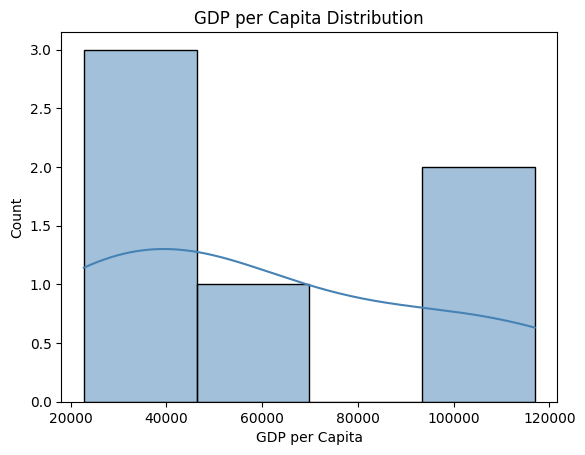

In [22]:
# a. univariate analysis on gdp_per_capita using distplot
sns.histplot(df_groupby['gdp_per_capita'], kde=True, color='steelblue')
plt.title('GDP per Capita Distribution')
plt.xlabel('GDP per Capita')
plt.savefig('chart_1_gdp_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


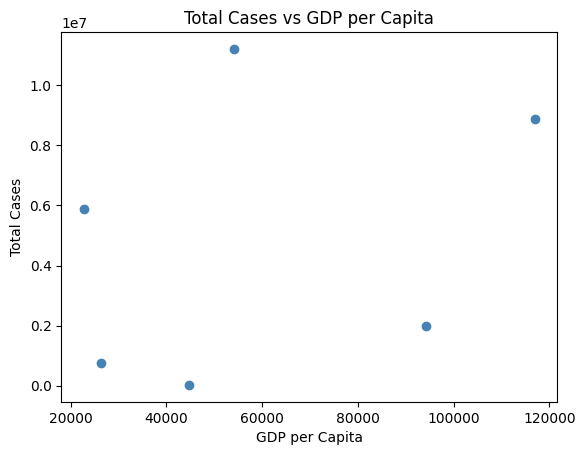

In [23]:
# b. scatter plot of total_cases and gdp_per_capita
plt.scatter(df_groupby['gdp_per_capita'], df_groupby['total_cases'], color='steelblue')
plt.title('Total Cases vs GDP per Capita')
plt.xlabel('GDP per Capita')
plt.ylabel('Total Cases')
plt.savefig('chart_2_cases_vs_gdp.png', dpi=150, bbox_inches='tight')
plt.show()


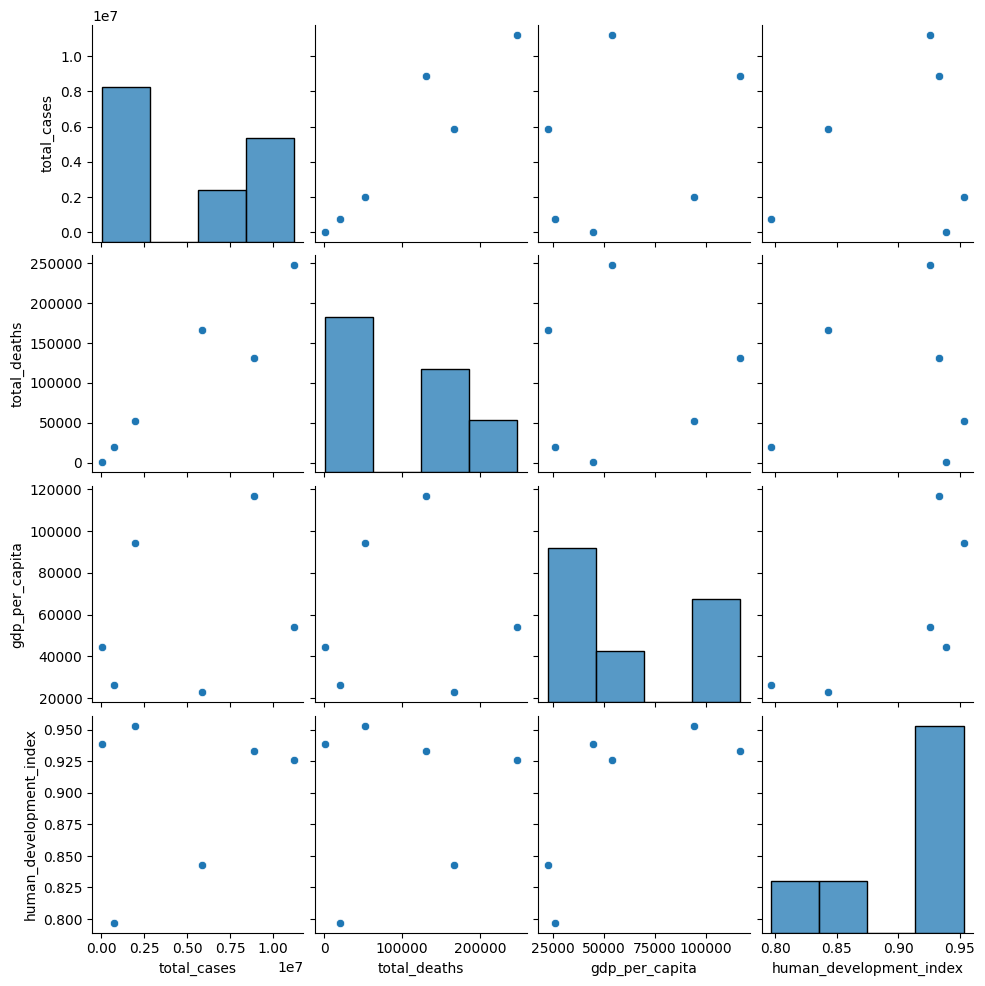

In [24]:
# c. pairplot on df_groupby
sns.pairplot(df_groupby[['total_cases','total_deaths','gdp_per_capita','human_development_index']])
plt.savefig('chart_3_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()


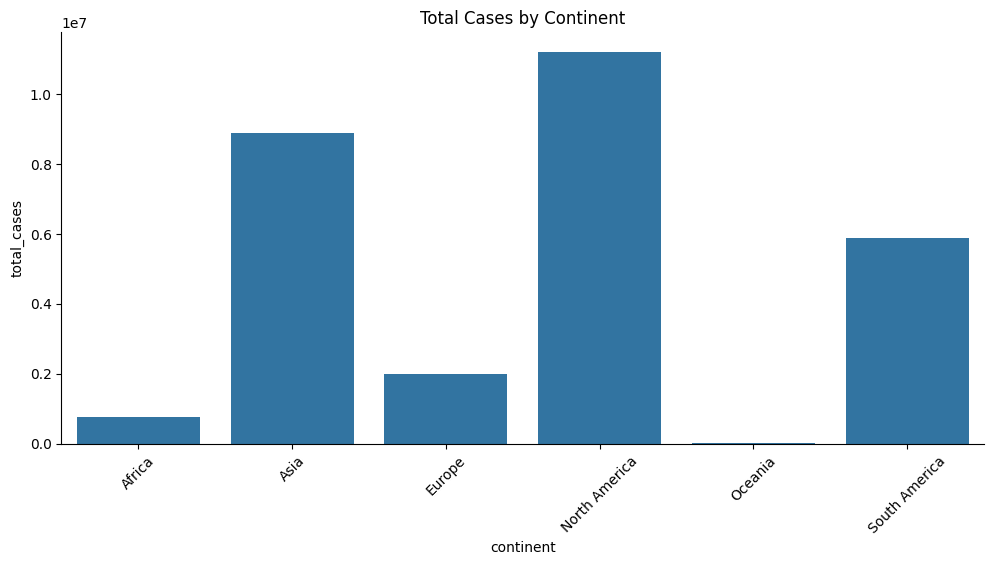

In [25]:
# d. bar plot of continent vs total_cases
sns.catplot(data=df_groupby, x='continent', y='total_cases', kind='bar', height=5, aspect=2)
plt.title('Total Cases by Continent')
plt.xticks(rotation=45)
plt.savefig('chart_4_continent_cases.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Save the Dataframe


In [26]:
df_groupby.to_csv('covid_analysis.csv', index=False)
print('Saved successfully')


Saved successfully
